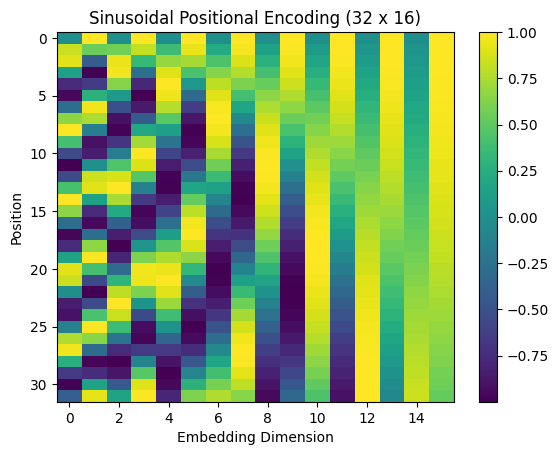

In [2]:
import torch
import math
import matplotlib.pyplot as plt

d_model = 16
max_len = 32
# max_len = 128

pe = torch.zeros(max_len, d_model)
position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
# div_term = torch.exp(
#     torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
# )

div_term = torch.exp(
    torch.arange(0, d_model, 2).float() * (-math.log(50) / d_model)
)


pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

pe_np = pe.numpy()

plt.figure()
plt.imshow(pe_np, aspect='auto')
plt.colorbar()
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title("Sinusoidal Positional Encoding (32 x 16)")
plt.show()

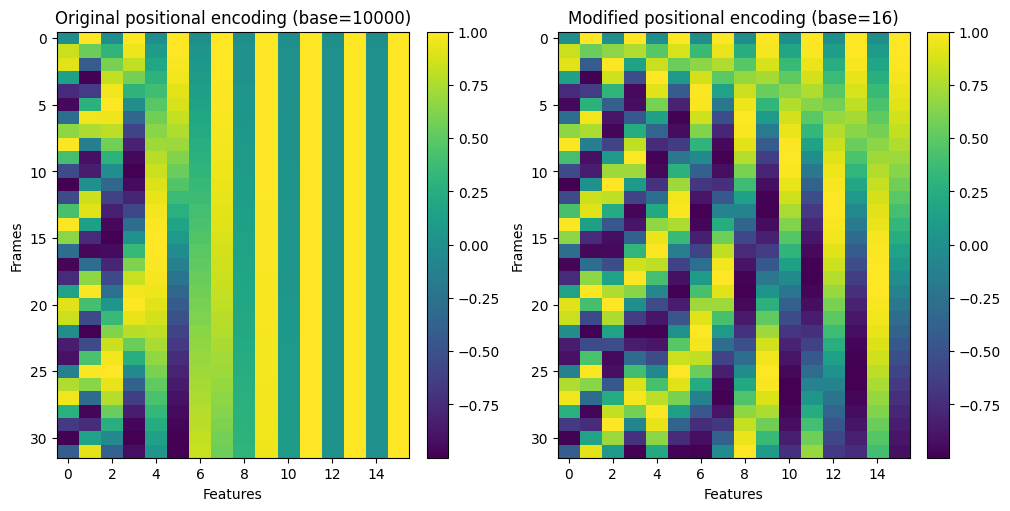

In [28]:
import math
import torch
import matplotlib.pyplot as plt

d_model = 16
max_len = 32

pe_original = torch.zeros(max_len, d_model)
position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)

div_term_original = torch.exp(
    torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model)
)

pe_original[:, 0::2] = torch.sin(position * div_term_original)
pe_original[:, 1::2] = torch.cos(position * div_term_original)

pe_modified = torch.zeros(max_len, d_model)

div_term_modified = torch.exp(
    torch.arange(0, d_model, 2).float() * (-math.log(16.0) / d_model)
)

pe_modified[:, 0::2] = torch.sin(position * div_term_modified)
pe_modified[:, 1::2] = torch.cos(position * div_term_modified)

pe_original_np = pe_original.numpy()
pe_modified_np = pe_modified.numpy()

fig, axes = plt.subplots(1, 2, figsize=(10, 5), constrained_layout=True)

im1 = axes[0].imshow(pe_original_np, aspect='auto')
axes[0].set_title("Original positional encoding (base=10000)")
axes[0].set_xlabel("Features")
axes[0].set_ylabel("Frames")
fig.colorbar(im1, ax=axes[0])

# Right subplot
im2 = axes[1].imshow(pe_modified_np, aspect='auto')
axes[1].set_title("Modified positional encoding (base=16)")
axes[1].set_xlabel("Features")
axes[1].set_ylabel("Frames")
fig.colorbar(im2, ax=axes[1])

plt.savefig("positional_encoding_comparison.pdf", bbox_inches='tight')
plt.show()

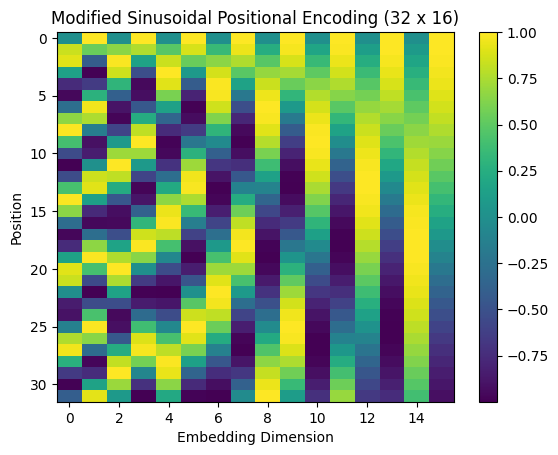

In [4]:
import torch
import math
import matplotlib.pyplot as plt

d_model = 16
max_len = 32
# max_len = 128

pe = torch.zeros(max_len, d_model)
position = torch.arange(0, max_len, dtype=torch.float).unsqueeze(1)
div_term = torch.exp(
    torch.arange(0, d_model, 2).float() * (-math.log(16.0) / d_model)
)

pe[:, 0::2] = torch.sin(position * div_term)
pe[:, 1::2] = torch.cos(position * div_term)

pe_np = pe.numpy()

plt.figure()
plt.imshow(pe_np, aspect='auto')
plt.colorbar()
plt.xlabel("Embedding Dimension")
plt.ylabel("Position")
plt.title(f"Modified Sinusoidal Positional Encoding ({max_len} x {d_model})")
plt.show()